# Volume 4: Wave Equation
    <Name>
    <Class>
    <Date>

In [28]:
import numpy as np
from matplotlib import pyplot as plt, animation as ani
from scipy import sparse, optimize

ani.writer = ani.writers["ffmpeg"]

# Problem 1

Define a function `solve_wave` to numerically approximate solutions to equations of the form

$$\begin{align*}
	u_{tt} &= s^2 u_{xx}, \quad 0 < x < l, \quad t > 0,\\
	u(0,t) &= u(l,t) = 0, \\
	u(x,0) &= f(x),\\
	u_t(x,0) &= g(x).
\end{align*}$$

Return the numerical approximation $U$ as an array.

In [29]:
def solve_wave(x_bounds, t_bounds, J, M, s, f, g): 
    # Make parameters 
    delta_x = (x_bounds[1] - x_bounds[0]) / J 
    delta_t = (t_bounds[1] - t_bounds[0]) / M 
    lamb = s * delta_t / delta_x 
    
    on = 2 * (1 - (lamb**2)) 
    off = lamb**2 

    # Make matrix 
    on_diag = np.full(J - 1, on) 
    off_diag = np.full(J - 2, off)
    A = sparse.diags([on_diag, off_diag, off_diag], [0, 1, -1]) 
    
    # Make U^0 (the state at t=0 for all x values) 
    xs = np.linspace(x_bounds[0], x_bounds[1], J + 1) 
    U_at_0 = f(xs)[1:-1] # I don't like the indexing here 
    
    # Make U^1 using equation 5 
    first = U_at_0 
    second = g(xs)[1:-1] * delta_t 
        # I think I have to make a matrix thing (which is upsetting)
    new_on_diag = np.full(J - 1, -2.0) 
    new_off_diag = np.full(J - 2, 1.0) 
    
    new_A = lamb * lamb * 0.5 * sparse.diags([new_on_diag, new_off_diag, new_off_diag], [0, 1, -1]) 
    third = new_A @ U_at_0 
        # Put it all together 
    U_at_1 = first + second + third # 

    interior_solutions = [U_at_0, U_at_1]
    
    for _ in range(2, M + 1): 
        u_next = A @ interior_solutions[-1] - interior_solutions[-2]
        interior_solutions.append(u_next) 

    full_solutions = []
    for u in interior_solutions:
        full_solutions.append(np.pad(u, (1, 1), mode='constant', constant_values=0))

    return full_solutions 

# Problem 2
Numerically approximate the solution to the following BVP

$$
u_{tt} = u_{xx} \\
u(0,t) = u(1,t) = 0, \\
u(x,0) = \sin(2\pi x), \\
u_t(x,0) = 0. 
$$

Numerically approximate the solution $u(x,t)$ for $t\in[0,0.5]$. Use $J=50$ subintervals in the $x$ dimension and $M=50$ subintervals in the $t$ dimension. Animate the results. Compare you results with the analytic solution $u(x,t) = \sin(2\pi x)\cos(2\pi t).$ This function is know as a standing wave.

In [30]:
def animation(filename, x_bounds, t_bounds, J, M, s, f, g):
    # Solve
    U = solve_wave(x_bounds, t_bounds, J, M, s, f, g)

    # Domains
    xs = np.linspace(x_bounds[0], x_bounds[1], J + 1)
    ts = np.linspace(t_bounds[0], t_bounds[1], M + 1)

    # Fig, ax
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    plt.xlim(x_bounds)
    plt.ylim(-1, 1)

    # Add labels
    plt.title("Solution")
    plt.xlabel("x")
    plt.ylabel("U")

    # Line object
    line, = ax.plot([], [], "-", color="blue")

    # Update
    def update(t):
        line.set_data(xs, U[t])
    
    # All together now
    anim = ani.FuncAnimation(fig, update, frames=range(len(ts)), interval=20)

    anim.save(filename)

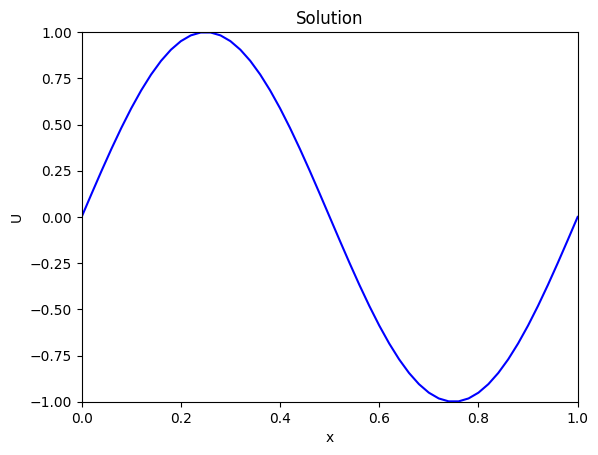

In [31]:
x_bounds = (0, 1)
t_bounds = (0, 0.5)
J = 50
M = 50
s = 1
f = lambda x: np.sin(2 * np.pi * x)
g = lambda x: np.zeros_like(x)
# solution = solve_wave(x_bounds, t_bounds, J, M, s, f, g)

animation("prob2.mp4", x_bounds, t_bounds, J, M, s, f, g)


<video src="prob2.mp4" controls>

# Problem 3

Consider the boundary value problem 

$$
u_{tt} = u_{xx}, \\
u(0,t) = u(1,t) = 0, \\
u(x,0) = 0.2e^{-m^2 \left(x - \frac 1 2 \right)^2} \\
u_t(x,0) = 0.4m^2 \left(x - \frac 1 2 \right)e^{-m^2 \left(x - \frac 1 2 \right)^2}.
$$

The solution of this problem is a Gaussian pulse. It travels to the right at a constant speed. This solution models, for example, a wave pulse in a stretched string. Note that the fixed boundary conditions reflect the pulse back when it meets the boundary.

Numerically approximate the solution $u(x,t)$ for $t\in[0,1]$. Set $m=20$. Use 200 subintervals in space and 220 in time, and animate your results. Then use 200 subintervals in space and 180 in time, and animate your results. Note that the stability condition is not satisfied for the second mesh.

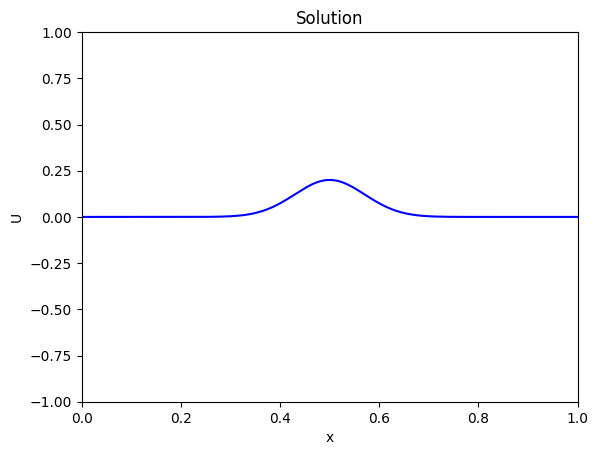

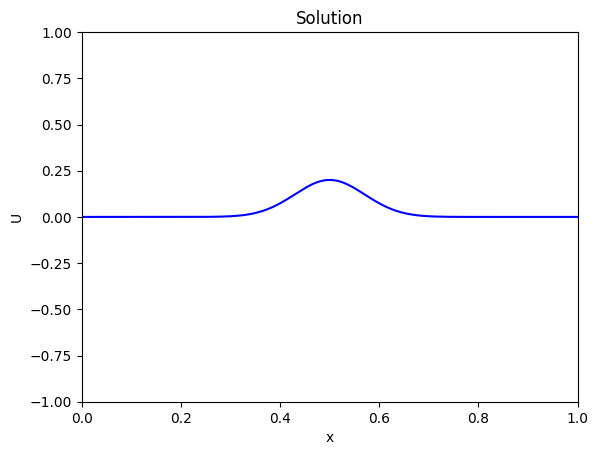

In [32]:
# Part 1
x_bounds = (0, 1)
t_bounds = (0, 1)
J = 200
M = 220
s = 1 # The coefficient on u_{xx}
m = 10 # What is this??????????
f = lambda x: 0.2 * np.exp(-1 * (m**2) * ((x - 0.5) ** 2))
g = lambda x: 0.4 * m * m * (x - 0.5) * np.exp(np.exp(-1 * (m**2) * ((x - 0.5) ** 2)))
# solution = solve_wave(x_bounds, t_bounds, J, M, s, f, g)

animation("prob3_part_1.mp4", x_bounds, t_bounds, J, M, s, f, g)

# Part 2
x_bounds = (0, 1)
t_bounds = (0, 1)
J = 200
M = 180
s = 1 # The coefficient on u_{xx}
m = 10 # What is this??????????
f = lambda x: 0.2 * np.exp(-1 * (m**2) * ((x - 0.5) ** 2))
g = lambda x: 0.4 * m * m * (x - 0.5) * np.exp(-1 * (m**2) * ((x - 0.5) ** 2))
# solution = solve_wave(x_bounds, t_bounds, J, M, s, f, g)

animation("prob3_part_2.mp4", x_bounds, t_bounds, J, M, s, f, g)

<video src="prob3_part_1.mp4" controls>

<video src="prob3_part_2.mp4" controls>

# Problem 4

Consider the initial boundary value problem
$$
	u_{tt} = u_{xx}, \\
	u(0,t) = u(1,t) = 0, \\
	u(x,0) = 0.2e^{-m^2(x-1/2)^2}\\
	u_t(x,0) = 0.
$$
The initial condition separates into two smaller, slower-moving pulses, one travelling to the right and the other to the left.
This solution models, for example, a plucked guitar string

Numerically approximate the solution $u(x,t)$ for $t \in \left[0,2\right]$.
Set $m=20$.
Use 200 subintervals in space and 440 in time, and animate your results.
It is rather easy to see that the solution to this problem is the sum of two travelling waves, one travelling to the left and the other to the right, as described earlier.

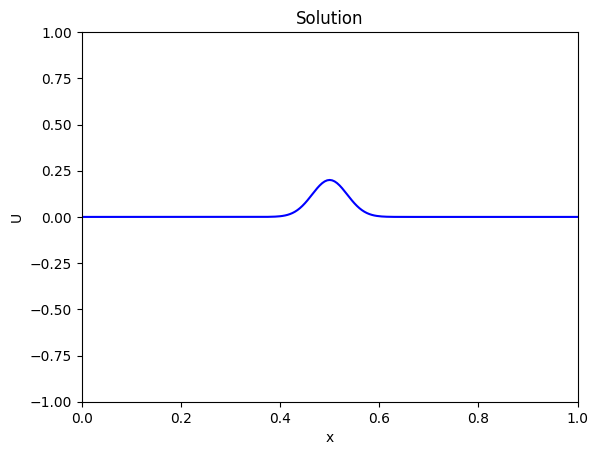

In [33]:
x_bounds = (0, 1)
t_bounds = (0, 2)
J = 200 # Space intervals
M = 440
s = 1 # The coefficient on u_{xx}
m = 20 # What is this??????????
f = lambda x: 0.2 * np.exp(-1 * (m**2) * ((x - 0.5) ** 2))
g = lambda x: np.zeros_like(x)
# solution = solve_wave(x_bounds, t_bounds, J, M, s, f, g)

animation("prob4.mp4", x_bounds, t_bounds, J, M, s, f, g)

<video src="prob4.mp4" controls>

# Problem 5

Consider the initial boundary value problem

$$
	u_{tt} = u_{xx}, \\
	u(0,t) = u(1,t) = 0, \\
	u(x,0) = \begin{cases} 1/3 & \text{if } 5/11 < x < 6/11,\\
	0 & \text{otherwise}
	\end{cases}\\
	u_t(x,0) = 0.
$$

Numerically approximate the solution $u(x,t)$ for $t \in \left[0, 2\right]$.
Use 200 subintervals in space and 440 in time, and animate your results.
Even though the method is second order and stable for this discretization, since the initial condition is discontinuous there are large dispersive errors.

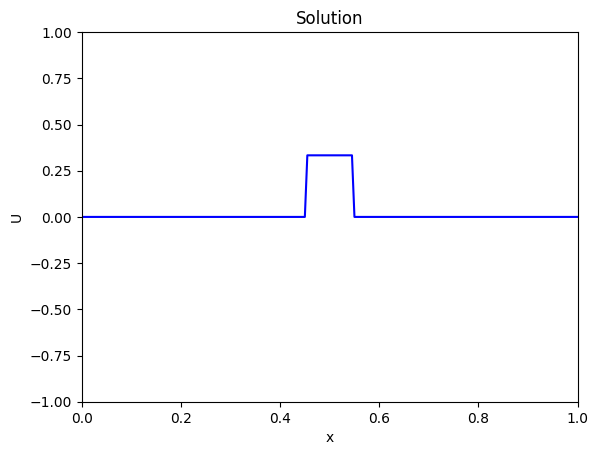

In [34]:
x_bounds = (0, 1)
t_bounds = (0, 2)
J = 200 # Space intervals
M = 440
s = 1 # The coefficient on u_{xx}
# f = lambda x: 1/3 if x < 6/11 and x > 5/11 else 0
def f(x):
    return np.where((x > 5/11) & (x < 6/11), 1/3, 0)
g = lambda x: np.zeros_like(x)
# solution = solve_wave(x_bounds, t_bounds, J, M, s, f, g)

animation("prob5.mp4", x_bounds, t_bounds, J, M, s, f, g)

<video src="prob5.mp4" controls>

# Problem 6

Solve the 2D wave equation $(11)$.
Use $N = 200$ spatial subintervals and $M = 500$ time subintervals.
Use a spatial domain $(x, y) \in [-10, 10] \times [-10, 10]$ and a time domain $t \in (t_0, t_f) = (0, 40)$.
Set $f(x, y) = 3 \frac 1 {2 \pi} \exp \left(-\frac12 \left(x^2 + y^2
\right) \right)$, and set $g(x, y) = 0$.
Finally, use $\alpha = 0.8$.
Animate the result, and compare with Figure 5.
Remember to use sparse matrices.

Hint: You may find useful the functions `scipy.sparse.diags`, `scipy.sparse.block_diag`, and `<sparse_matrix>.setdiag`.
Also note that $f(x, y)$ is equal to 3 times the probability density function of the standard two-dimensional normal distribution.

In [ ]:
# The usual setup
x_y_domain = ((-10, -10), (10, 10))
time_domain = (0, 40)
J = 200 # Space intervals
M = 500
f = lambda x, y: (1.5 / np.pi) * np.exp(-0.5 * (x * x + y * y))
g = lambda x, y: np.zeros_like(x)
alpha = 0.8
delta_x = (x_y_domain[1][0] - x_y_domain[0][0]) / J
delta_y = delta_x
h = delta_x
delta_t = (time_domain[1] - time_domain[0]) / M


x = np.linspace(x_y_domain[0][0] + delta_x, x_y_domain[1][0] - delta_x, J - 1) 
y = np.linspace(x_y_domain[0][1] + delta_y, x_y_domain[1][1] - delta_y, J - 1) 
X, Y = np.meshgrid(x, y)

# The equation setup
lamb = (alpha * alpha * delta_t * delta_t) / (h ** 2)

Lambda = sparse.eye(J - 1) * lamb

on_diag = np.full(J - 1, 2 - (4 * lamb))
off_diag = np.full(J - 2, lamb)
T = sparse.diags([on_diag, off_diag, off_diag], [0, -1, 1])

# Have to make A as its own thing
blocks = [[None for _ in range(J - 1)] for _ in range(J - 1)]
for i in range(J - 1):
    blocks[i][i] = T # Diagonal
    if i > 0:
        blocks[i][i-1] = Lambda # Off-diagonal
    if i < (J) - 2:
        blocks[i][i+1] = Lambda # Other off-diagonal
A = sparse.bmat(blocks)
# No idea how to test that, so that'll be fun

# Start I guess
U = []
U.append(np.array(f(X, Y)).flatten())

# Have to make U_1 which is gonna suck
U.append(0.5 * A @ U[0]) # Ignoring this for now

def stepper(U):
    return A @ U[-1] - U[-2]

# Try to run it?
while len(U) <= M:
    U.append(stepper(U))

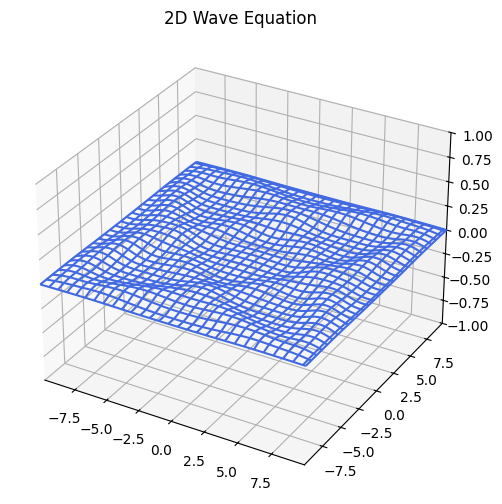

In [ ]:
def animation_3d(U, X, Y, filename):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    
    # Set static axes limits
    ax.set_xlim([X.min(), X.max()])
    ax.set_ylim([Y.min(), Y.max()])
    ax.set_zlim([-1.0, 1.0]) 
    ax.set_title("2D Wave Equation")

    # Plot initial state with 10 lines in each direction
    Z_initial = U[0].reshape(X.shape)
    wire = [ax.plot_wireframe(X, Y, Z_initial, color='royalblue', rcount=30, ccount=30)]

    def update(frame_idx):
        wire[0].remove()
        
        Z_current = U[frame_idx].reshape(X.shape)
        wire[0] = ax.plot_wireframe(X, Y, Z_current, color='royalblue', rcount=30, ccount=30)
            
        return wire

    
    anim = ani.FuncAnimation(fig, update, frames=len(U), blit=False, interval=30)
    
    anim.save(filename)


animation_3d(U, X, Y, "prob6.mp4")

<video src="prob6.mp4" controls>